# Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the Dataset

In [4]:
df = pd.read_csv('sales_data_with_discounts.csv')


In [5]:
print('Dataset Shape:', df.shape)
print('First 5 Rows:')
df.head()

Dataset Shape: (450, 13)
First 5 Rows:


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.50120
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102960,89323.89704
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910160,102042.08980
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.92530
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.05377


# Identify Numerical Columns

In [6]:
print('Dataset Info:')
df.info(),
print('Missing Values:'),
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB
Missing Values:
Date                 0
Day                  0
SKU                  0
City         

In [7]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical Columns:', numerical_cols)


Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


# Calculate Statistical Measures

In [8]:
stats_df= pd.DataFrame({
                        'Mean': df[numerical_cols].mean(),
                        'Median': df[numerical_cols].median(),
                        'Mode': df[numerical_cols].mode().iloc[0],
                        'Standard_Deviation': df[numerical_cols].std(),
                        'Min':   df[numerical_cols].min(),
                        'Max':   df[numerical_cols].max()
                       })
print('Descriptive Statistics:'),
stats_df


                       

Descriptive Statistics:


,Mean,Median,Mode,Standard_Deviation,Min,Max
Volume,5.066667,4.000000,3.000000,4.231602,1.000000,31.000000
Avg Price,10453.433333,1450.000000,400.000000,18079.904840,290.000000,60100.000000
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173,400.000000,196400.000000
Discount Rate (%),15.155242,16.577766,5.007822,4.220602,5.007822,19.992407
Discount Amount,3346.499424,988.933733,69.177942,4509.902963,69.177942,25738.022190
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624,326.974801,179507.479000


# Data Visualization

## Histograms

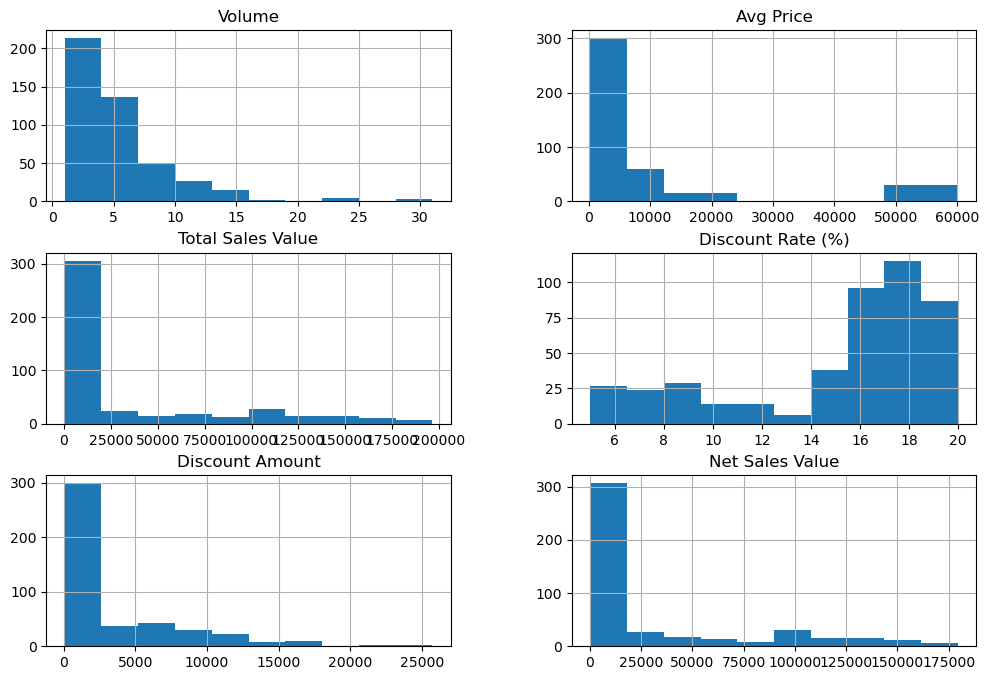

In [9]:
import matplotlib.pyplot as plt
df[numerical_cols].hist(figsize=(12,8))
plt.show()

### Boxplots

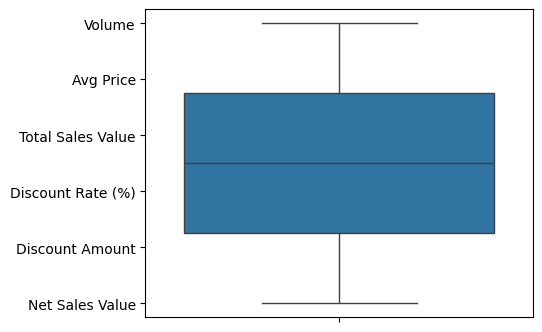

In [10]:
import seaborn as sns 
plt.figure(figsize=(5,4))
sns.boxplot(data=numerical_cols)
plt.xticks(rotation=45)
plt.show()

## Bar Chart Analysis for Categorical Columns

In [11]:
categorial_cols=df.select_dtypes(include=['object'])
print(categorial_cols.columns)

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


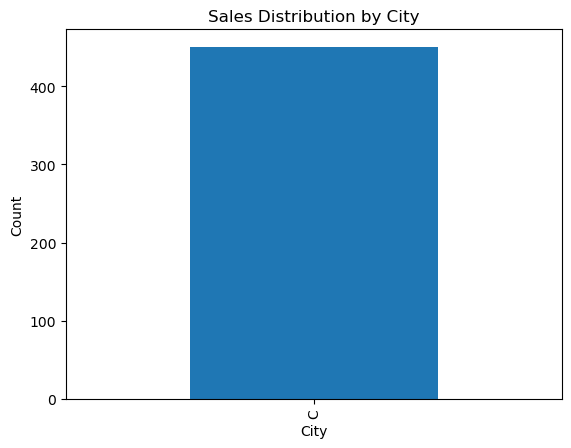

In [12]:
# Bar chart
df['City'].value_counts().plot(kind='bar')
plt.title("Sales Distribution by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()


## Standardization of Numerical Variables

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])
scaled_df = pd.DataFrame(scaled_data, columns=numerical_cols)
print(scaled_df.head())

     Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0  2.350029   0.091173           2.925721          -0.830289         3.952816   
1  1.167129  -0.019570           1.330995          -0.852661         1.849014   
2  0.457388   0.312659           1.562775          -1.351631         1.622995   
3  0.220808   0.534146           1.719276          -1.949723         1.113807   
4 -0.488932  -0.130313          -0.188452           0.673739         0.227852   

   Net Sales Value  
0         2.804756  
1         1.271026  
2         1.545675  
3         1.765810  
4        -0.227595  


In [18]:
# Before vs After Comparison
print(df[numerical_cols].describe())
print(scaled_df.describe())

           Volume     Avg Price  Total Sales Value  Discount Rate (%)  \
count  450.000000    450.000000         450.000000         450.000000   
mean     5.066667  10453.433333       33812.835556          15.155242   
std      4.231602  18079.904840       50535.074173           4.220602   
min      1.000000    290.000000         400.000000           5.007822   
25%      3.000000    465.000000        2700.000000          13.965063   
50%      4.000000   1450.000000        5700.000000          16.577766   
75%      6.000000  10100.000000       53200.000000          18.114718   
max     31.000000  60100.000000      196400.000000          19.992407   

       Discount Amount  Net Sales Value  
count       450.000000       450.000000  
mean       3346.499424     30466.336131  
std        4509.902963     46358.656624  
min          69.177942       326.974801  
25%         460.459304      2202.208645  
50%         988.933733      4677.788059  
75%        5316.495426     47847.912855  
max   

## Conversion of Categorical Data into Dummy Variables

In [23]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns = categorical_cols)
print(df_encoded.head())

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102960   
2       7      16100             112700           9.456886     10657.910160   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  Date_01-04-2021  Date_02-04-2021  Date_03-04-2021  \
0     160346.50120             True            False            False   
1      89323.89704             True            False            False   
2     102042.08980             True            False            False   
3     112235.92530             True            False            False   
4      19927.05377             True            False            False   

   Date_04-04-2021  ...  Model_Vedic Cream  Model_Vedic Oil  \
0            False  ...

## Conclusion

## Numerical columns revealed insights about sales patterns, pricing, and discounts.

## Histograms and boxplots helped identify data distribution and potential outliers.

## Bar charts showed the frequency of categorical variables such as cities and brands.

## Standardization ensured numerical variables are on a uniform scale, improving model performance.

## One-hot encoding transformed categorical variables into machine-learning-friendly numeric format.